# Hodgkin-Huxley — Spiking with Forced i_Stim

Compiles the Hodgkin-Huxley squid axon model, overrides the algebraic
stimulus current `i_Stim` via the runtime forcing vector, and integrates
with a stiff Runge-Kutta solver (Radau).  Time is in **ms**.

Step through the cells in order.  Edit any settings cell and re-run from there.


In [1]:
import sys
import pathlib
import numpy as np

_root = next(
    p
    for p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]
    if (p / "src" / "cellml2py").exists()
)
for _p in [str(_root / "src"), str(_root / "examples")]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

In [2]:
from cellml2py import CompileOptions, OverrideSpec, compile_cellml, simulate
from example_utils import build_injection_current, plot_voltage_and_current


In [3]:
# --- model path + compile options ---
model_path = _root / "data/opencor_models/hodgkin_huxley_squid_axon_model_1952.cellml"

# Override i_Stim so the solver can inject current via the forcing vector.
options = CompileOptions(
    override_targets=(OverrideSpec(target="i_Stim", kind="algebraic"),)
)
model = compile_cellml(model_path, backend="numpy", options=options)
print(
    f"compiled  states={model.initial_state.size}  forcing={model.layout.forcing_names}"
)

compiled  states=4  forcing=('i_Stim',)


In [4]:
# --- injection-current settings ---
forcing_mode = "constant"  # 'constant' or 'pulse'
constant_current = -100.0  # uA/cm^2  (negative = depolarising in HH)

# pulse-train geometry (used when forcing_mode = 'pulse')
amp = 20.0
pulse_start = 10.0  # ms
pulse_width = 2.0  # ms
pulse_interval = 15.0  # ms
n_pulses = 5

i_inj = build_injection_current(
    forcing_mode,
    constant_current,
    amp,
    pulse_start,
    pulse_width,
    pulse_interval,
    n_pulses,
)
forcing_fn = lambda t: [i_inj(t)]

In [5]:
# --- solver settings ---
t_end = 100.0  # ms
steps = 2001
method = "Radau"
max_step = 0.05  # ms  — tight cap keeps the stiff membrane stable

sol = simulate(
    model,
    (0.0, t_end),
    steps=steps,
    forcing=forcing_fn,
    method=method,
    max_step=max_step,
)
print(f"success={sol.success}   samples={sol.t.size}   message: {sol.message}")

success=True   samples=2001   message: The solver successfully reached the end of the integration interval.


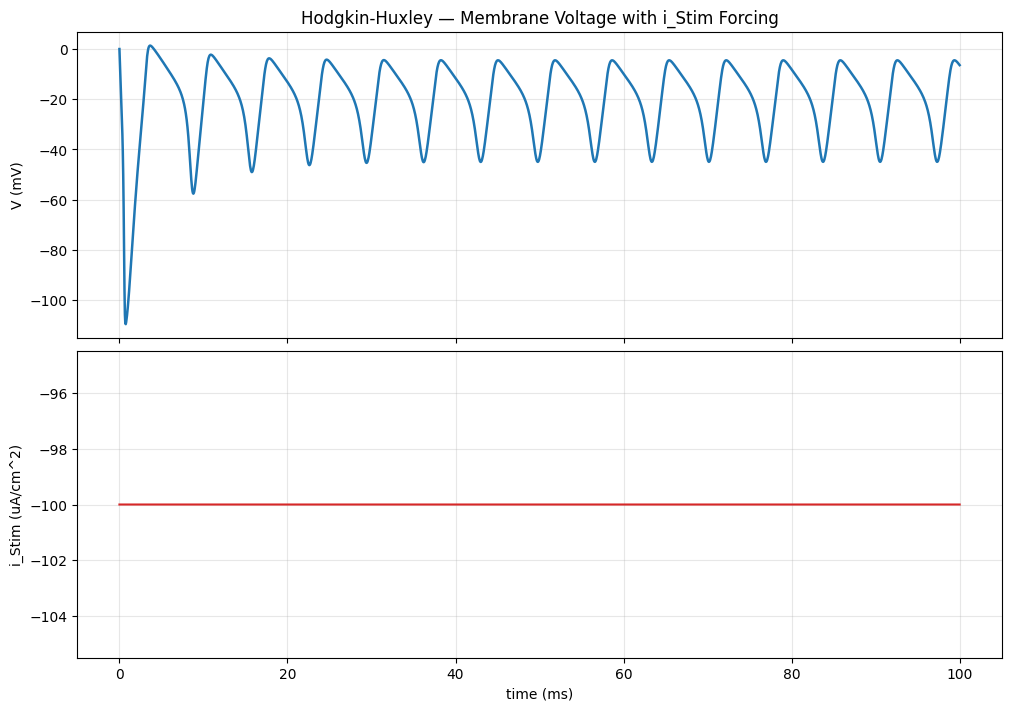

WindowsPath('hh_spiking_forced.png')

In [6]:
current_trace = np.array([i_inj(float(t)) for t in sol.t])

plot_voltage_and_current(
    sol.t,
    sol.y[0],
    current_trace,
    title="Hodgkin-Huxley — Membrane Voltage with i_Stim Forcing",
    time_label="time (ms)",
    current_label="i_Stim (uA/cm^2)",
    plot_path="hh_spiking_forced.png",
    show=True,
)